## Load the dataset

Below, I am beginning this project by loading the dataset saved in the file 'profiles.csv' and storing it in the variable **df**.

Then, I will run the .head() and .info() functions to get a preview of the data. As you can see at a first glance, there are some columns with missing values. You can also see that many of the values are objects. Later, we will go through and transform the relevant columns to this machine learning model into categorical values.

In [1]:
import pandas as pd
import numpy as np
from html import unescape

from matplotlib import pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, RandomForestRegressor
from sklearn import tree
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

In [2]:
df = pd.read_csv('profiles.csv')

In [3]:
df.head()

,age,body_type,diet,drinks,drugs,education,essay0,essay1,essay2,essay3,...,location,offspring,orientation,pets,religion,sex,sign,smokes,speaks,status
0,22,a little extra,strictly anything,socially,never,working on college/university,about me:<br />\n<br />\ni would love to think...,currently working as an international agent fo...,making people laugh.<br />\nranting about a go...,"the way i look. i am a six foot half asian, ha...",...,"south san francisco, california","doesn&rsquo;t have kids, but might want them",straight,likes dogs and likes cats,agnosticism and very serious about it,m,gemini,sometimes,english,single
1,35,average,mostly other,often,sometimes,working on space camp,i am a chef: this is what that means.<br />\n1...,dedicating everyday to being an unbelievable b...,being silly. having ridiculous amonts of fun w...,NaN,...,"oakland, california","doesn&rsquo;t have kids, but might want them",straight,likes dogs and likes cats,agnosticism but not too serious about it,m,cancer,no,"english (fluently), spanish (poorly), french (...",single
2,38,thin,anything,socially,NaN,graduated from masters program,"i'm not ashamed of much, but writing public te...","i make nerdy software for musicians, artists, ...",improvising in different contexts. alternating...,my large jaw and large glasses are the physica...,...,"san francisco, california",NaN,straight,has cats,NaN,m,pisces but it doesn&rsquo;t matter,no,"english, french, c++",available
3,23,thin,vegetarian,socially,NaN,working on college/university,i work in a library and go to school. . .,reading things written by old dead people,playing synthesizers and organizing books acco...,socially awkward but i do my best,...,"berkeley, california",doesn&rsquo;t want kids,straight,likes cats,NaN,m,pisces,no,"english, german (poorly)",single
4,29,athletic,NaN,socially,never,graduated from college/university,hey how's it going? currently vague on the pro...,work work work work + play,creating imagery to look at:<br />\nhttp://bag...,i smile a lot and my inquisitive nature,...,"san francisco, california",NaN,straight,likes dogs and likes cats,NaN,m,aquarius,no,english,single


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59946 entries, 0 to 59945
Data columns (total 31 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   age          59946 non-null  int64  
 1   body_type    54650 non-null  object 
 2   diet         35551 non-null  object 
 3   drinks       56961 non-null  object 
 4   drugs        45866 non-null  object 
 5   education    53318 non-null  object 
 6   essay0       54458 non-null  object 
 7   essay1       52374 non-null  object 
 8   essay2       50308 non-null  object 
 9   essay3       48470 non-null  object 
 10  essay4       49409 non-null  object 
 11  essay5       49096 non-null  object 
 12  essay6       46175 non-null  object 
 13  essay7       47495 non-null  object 
 14  essay8       40721 non-null  object 
 15  essay9       47343 non-null  object 
 16  ethnicity    54266 non-null  object 
 17  height       59943 non-null  float64
 18  income       59946 non-null  int64  
 19  job 

## Data exploration

Let's begin by taking a closer look at the dataset, starting with the columns with missing values. Which columns are missing the most values?

In [5]:
missing_values = df.isna().sum().sort_values(ascending=False)

In [6]:
print("Missing values:\n" + str(missing_values))

Missing values:
offspring      35561
diet           24395
religion       20226
pets           19921
essay8         19225
drugs          14080
essay6         13771
essay9         12603
essay7         12451
essay3         11476
sign           11056
essay5         10850
essay4         10537
essay2          9638
job             8198
essay1          7572
education       6628
ethnicity       5680
smokes          5512
essay0          5488
body_type       5296
drinks          2985
speaks            50
height             3
sex                0
age                0
orientation        0
location           0
last_online        0
income             0
status             0
dtype: int64


I'll now go in and get rid of the null values. Because these missing values come from the sections of dating profiles that were ignored/unanswered, I will fill them with the string "no answer".

In [7]:
df = df.fillna("no answer")

In [8]:
print("Missing values:\n" + str(df.isna().sum().sort_values(ascending=False)))

Missing values:
age            0
ethnicity      0
speaks         0
smokes         0
sign           0
sex            0
religion       0
pets           0
orientation    0
offspring      0
location       0
last_online    0
job            0
income         0
height         0
essay9         0
body_type      0
essay8         0
essay7         0
essay6         0
essay5         0
essay4         0
essay3         0
essay2         0
essay1         0
essay0         0
education      0
drugs          0
drinks         0
diet           0
status         0
dtype: int64


Now that all of the null values have been eliminated, let's clean up the data more by changing some of the column names to make the language clearer. The following column names will be transformed:
- 'speaks' will become 'languages'
- 'sign' will become 'astrological_sign'
- 'offspring' will become 'children'
- 'status' will become 'relationship_status'

In [9]:
df = df.rename(columns={'speaks': 'languages', 'sign': 'astrological_sign', 'offspring': 'children', 'status': 'relationship_status'})

Next, I'll clean up the content of the cell values by eliminating the HTML entity '&rsquo;':

In [10]:
df.replace("&rsquo;", "\'", regex=True, inplace=True)
df.replace('<br />', ' ', regex=True, inplace=True)
df.replace('\n', '', regex=True, inplace=True)
df.head()

,age,body_type,diet,drinks,drugs,education,essay0,essay1,essay2,essay3,...,location,children,orientation,pets,religion,sex,astrological_sign,smokes,languages,relationship_status
0,22,a little extra,strictly anything,socially,never,working on college/university,about me: i would love to think that i was so...,currently working as an international agent fo...,making people laugh. ranting about a good salt...,"the way i look. i am a six foot half asian, ha...",...,"south san francisco, california","doesn't have kids, but might want them",straight,likes dogs and likes cats,agnosticism and very serious about it,m,gemini,sometimes,english,single
1,35,average,mostly other,often,sometimes,working on space camp,i am a chef: this is what that means. 1. i am ...,dedicating everyday to being an unbelievable b...,being silly. having ridiculous amonts of fun w...,no answer,...,"oakland, california","doesn't have kids, but might want them",straight,likes dogs and likes cats,agnosticism but not too serious about it,m,cancer,no,"english (fluently), spanish (poorly), french (...",single
2,38,thin,anything,socially,no answer,graduated from masters program,"i'm not ashamed of much, but writing public te...","i make nerdy software for musicians, artists, ...",improvising in different contexts. alternating...,my large jaw and large glasses are the physica...,...,"san francisco, california",no answer,straight,has cats,no answer,m,pisces but it doesn't matter,no,"english, french, c++",available
3,23,thin,vegetarian,socially,no answer,working on college/university,i work in a library and go to school. . .,reading things written by old dead people,playing synthesizers and organizing books acco...,socially awkward but i do my best,...,"berkeley, california",doesn't want kids,straight,likes cats,no answer,m,pisces,no,"english, german (poorly)",single
4,29,athletic,no answer,socially,never,graduated from college/university,hey how's it going? currently vague on the pro...,work work work work + play,creating imagery to look at: http://bagsbrown....,i smile a lot and my inquisitive nature,...,"san francisco, california",no answer,straight,likes dogs and likes cats,no answer,m,aquarius,no,english,single


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59946 entries, 0 to 59945
Data columns (total 31 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   age                  59946 non-null  int64 
 1   body_type            59946 non-null  object
 2   diet                 59946 non-null  object
 3   drinks               59946 non-null  object
 4   drugs                59946 non-null  object
 5   education            59946 non-null  object
 6   essay0               59946 non-null  object
 7   essay1               59946 non-null  object
 8   essay2               59946 non-null  object
 9   essay3               59946 non-null  object
 10  essay4               59946 non-null  object
 11  essay5               59946 non-null  object
 12  essay6               59946 non-null  object
 13  essay7               59946 non-null  object
 14  essay8               59946 non-null  object
 15  essay9               59946 non-null  object
 16  ethn

Now let's go through each of the variables and clean up any data where necessary.

### Age

The histogram below shows the distribution of age broken down by sex.

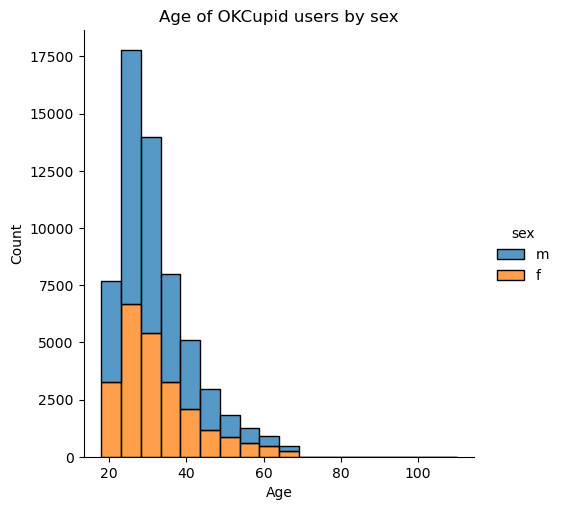

In [12]:
sns.displot(data=df, x='age', hue='sex', kind='hist', binwidth=5, multiple='stack')
plt.title("Age of OKCupid users by sex")
plt.xlabel("Age")
plt.show()

Most users are in their 20s and 30s. Across all ages, there are more men than women.

### Body type

The countplot below shows the distribution of different body types. The most common body types included in profiles are 'average', 'athletic', and 'fit'.

C:\Users\koral\AppData\Local\Temp\ipykernel_10464\2434110095.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='body_type', palette='deep')


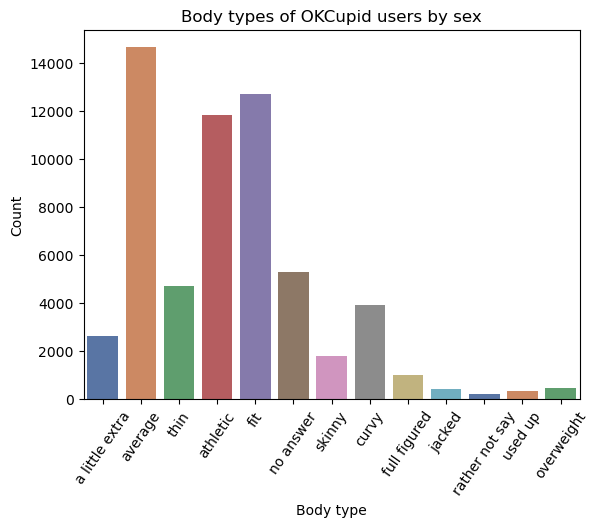

In [13]:
sns.countplot(data=df, x='body_type', palette='deep')
plt.title("Body types of OKCupid users by sex")
plt.xlabel("Body type")
plt.xticks(rotation=55)
plt.ylabel("Count")
plt.show()

### Diet

The countplot below shows the distribution of diets of users. The most answered option is 'no answer', followed by 'mostly anything', or at least that's how it seems.

C:\Users\koral\AppData\Local\Temp\ipykernel_10464\4052258524.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='diet', palette='deep')


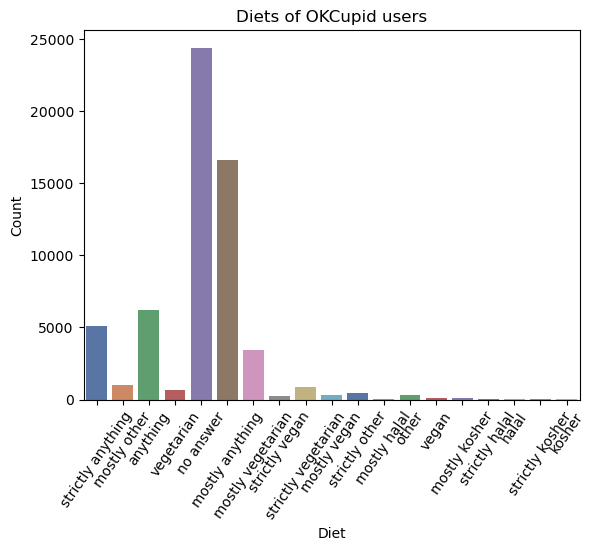

In [14]:
sns.countplot(data=df, x='diet', palette='deep')
plt.title("Diets of OKCupid users")
plt.xlabel("Diet")
plt.xticks(rotation=55)
plt.ylabel("Count")
plt.show()

This countplot is very messy with the x-ticks and x-tick labels not being properly aligned and the large number of options overall. I will adjust the data to merge responses together and see how that impacts the overall distribution. Any responses referring to a specific diet will be merged into one result. For example, the responses 'vegetarian', 'mostly vegetarian', and 'strictly vegetarian' will be merged under the label 'vegetarian.

In [15]:
df['diet'] = df['diet'].str.split().str[-1]

In [16]:
df['diet'].replace('answer', 'no answer', inplace=True)
print(df.head())

   age       body_type        diet    drinks      drugs  \
0   22  a little extra    anything  socially      never   
1   35         average       other     often  sometimes   
2   38            thin    anything  socially  no answer   
3   23            thin  vegetarian  socially  no answer   
4   29        athletic   no answer  socially      never   

                           education  \
0      working on college/university   
1              working on space camp   
2     graduated from masters program   
3      working on college/university   
4  graduated from college/university   

                                              essay0  \
0  about me:  i would love to think that i was so...   
1  i am a chef: this is what that means. 1. i am ...   
2  i'm not ashamed of much, but writing public te...   
3          i work in a library and go to school. . .   
4  hey how's it going? currently vague on the pro...   

                                              essay1  \
0  currentl

C:\Users\koral\AppData\Local\Temp\ipykernel_10464\724145217.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['diet'].replace('answer', 'no answer', inplace=True)


Now that the cell values have been reduced, let's see what the distribution of diets looks like.

C:\Users\koral\AppData\Local\Temp\ipykernel_10464\4052258524.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='diet', palette='deep')


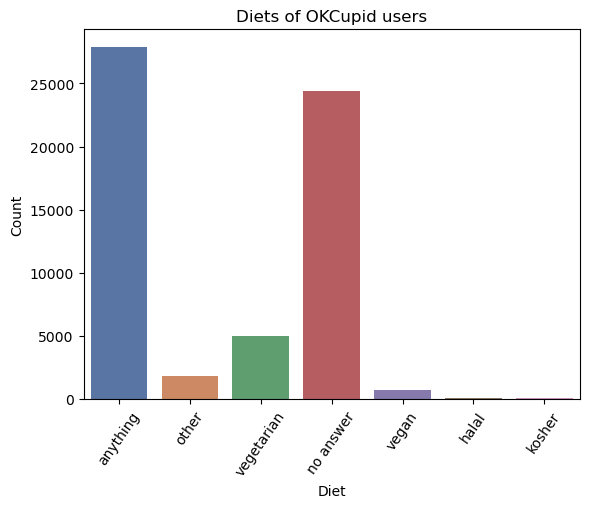

In [17]:
sns.countplot(data=df, x='diet', palette='deep')
plt.title("Diets of OKCupid users")
plt.xlabel("Diet")
plt.xticks(rotation=55)
plt.ylabel("Count")
plt.show()

### Drinks

Below is a countplot showing the drinking habits of users. Most users report being social drinkers.

C:\Users\koral\AppData\Local\Temp\ipykernel_10464\3271665181.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='drinks', palette='deep')


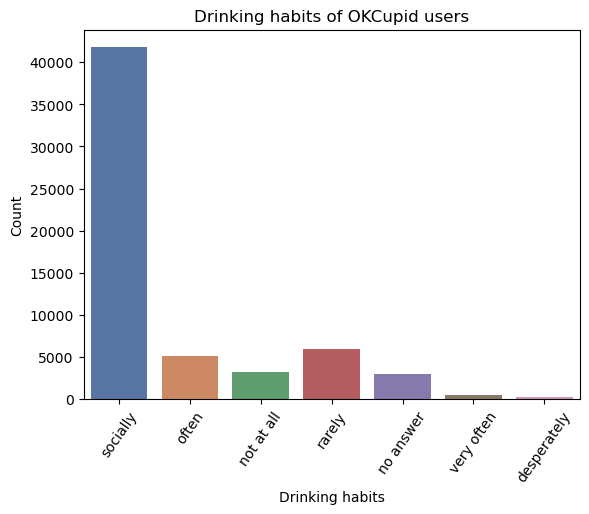

In [18]:
sns.countplot(data=df, x='drinks', palette='deep')
plt.title("Drinking habits of OKCupid users")
plt.xlabel("Drinking habits")
plt.xticks(rotation=55)
plt.ylabel("Count")
plt.show()

### Drugs

The countplot below shows the distribution of drug use habits by users. Most users report that they never use drugs.

C:\Users\koral\AppData\Local\Temp\ipykernel_10464\857013359.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='drugs', palette='deep')


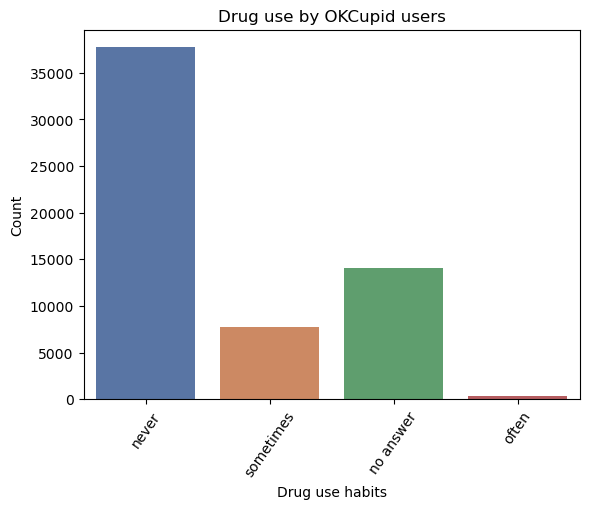

In [19]:
sns.countplot(data=df, x='drugs', palette='deep')
plt.title("Drug use by OKCupid users")
plt.xlabel("Drug use habits")
plt.xticks(rotation=55)
plt.ylabel("Count")
plt.show()

### Education

C:\Users\koral\AppData\Local\Temp\ipykernel_10464\167821323.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='education', palette='deep')


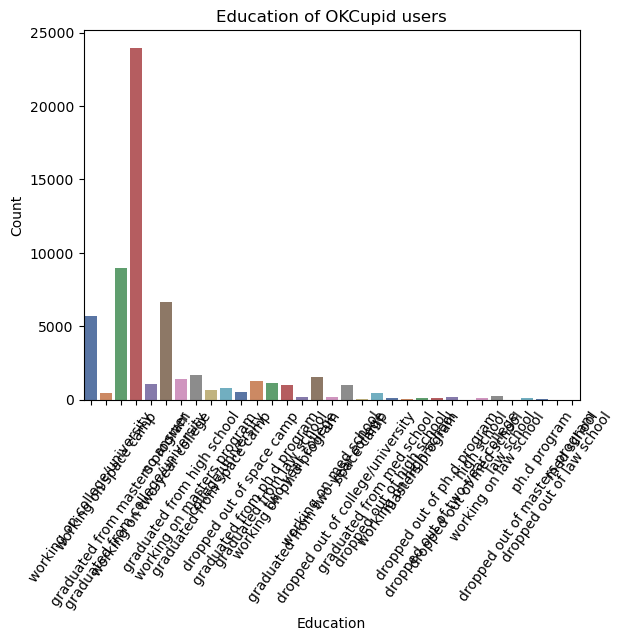

In [20]:
sns.countplot(data=df, x='education', palette='deep')
plt.title("Education of OKCupid users")
plt.xlabel("Education")
plt.xticks(rotation=55)
plt.ylabel("Count")
plt.show()

Like for *diet* above, there are several responses for *education* which crowd the countplot and make it difficult to read and interpret. I'm going to merge several of the education labels together similarly to what was done for *diet* earlier to reduce the number of responses.

In [21]:
df['education'].value_counts()

education
graduated from college/university    23959
graduated from masters program        8961
no answer                             6628
working on college/university         5712
working on masters program            1683
graduated from two-year college       1531
graduated from high school            1428
graduated from ph.d program           1272
graduated from law school             1122
working on two-year college           1074
dropped out of college/university      995
working on ph.d program                983
college/university                     801
graduated from space camp              657
dropped out of space camp              523
graduated from med school              446
working on space camp                  445
working on law school                  269
two-year college                       222
working on med school                  212
dropped out of two-year college        191
dropped out of masters program         140
masters program                        136
d

The *education* categories are merged such that any category mentioning a specific education level are merged together into a single category, with the exception of categories mentioning "dropped out of X". For those categories, they are merged into the next highest education level. For instance, if someone's profiles says "dropped out of ph.d program", then that has now been updated to say "masters" because that would be their highest completed level of education. The exception to this is "dropped out of space camp" and "dropped out of high school", which were left intact.

In [22]:
df['education'] = df['education'].replace({'graduated from college/university': 'college/university', 'graduated from masters program': 'masters',
                                          'working on college/university': 'college/university', 'working on masters program': 'masters',
                                          'graduated from two-year college': 'two-year college', 'graduated from high school': 'high school',
                                          'graduated from ph.d program': 'ph.d program', 'graduated from law school': 'law school',
                                          'working on two-year college': 'two-year college', 'working on ph.d program': 'ph.d program',
                                          'graduated from space camp': 'space camp', 'graduated from med school': 'med school',
                                          'working on space camp': 'space camp', 'working on law school': 'law school',
                                           'working on med school': 'med school', 'working on high school': 'high school',
                                           'dropped out of college/university': 'high school', 'dropped out of two-year college': 'high school',
                                          'dropped out of masters program': 'college/university', 'dropped out of ph.d program': 'masters',
                                          'dropped out of law school': 'college/university', 'dropped out of med school': 'college/university'})

In [23]:
df['education'].value_counts()

education
college/university            30642
masters                       10771
no answer                      6628
two-year college               2827
high school                    2797
ph.d program                   2281
law school                     1410
space camp                     1160
med school                      669
dropped out of space camp       523
masters program                 136
dropped out of high school      102
Name: count, dtype: int64

C:\Users\koral\AppData\Local\Temp\ipykernel_10464\3983824080.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='education', palette='deep')


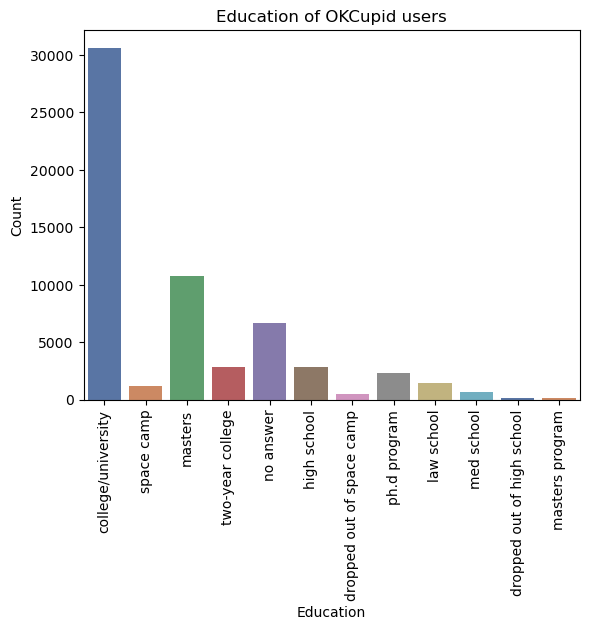

In [24]:
sns.countplot(data=df, x='education', palette='deep')
plt.title("Education of OKCupid users")
plt.xlabel("Education")
plt.xticks(rotation=90)
plt.ylabel("Count")
plt.show()

### Height

In [25]:
df.height.value_counts()

height
70.0    6074
68.0    5449
67.0    5354
72.0    5315
69.0    5179
        ... 
3.0        1
8.0        1
93.0       1
52.0       1
4.0        1
Name: count, Length: 61, dtype: int64

C:\Users\koral\AppData\Local\Temp\ipykernel_10464\4147807842.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='height', palette='deep')


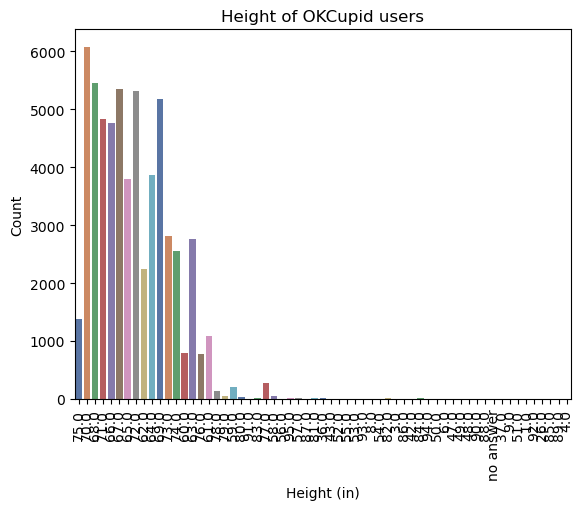

In [26]:
sns.countplot(data=df, x='height', palette='deep')
plt.title("Height of OKCupid users")
plt.xlabel("Height (in)")
plt.xticks(rotation=90)
plt.ylabel("Count")
plt.show()

### Income

### Job

### Location

### Children

In [27]:
df.children.value_counts()

children
no answer                                  35561
doesn't have kids                           7560
doesn't have kids, but might want them      3875
doesn't have kids, but wants them           3565
doesn't want kids                           2927
has kids                                    1883
has a kid                                   1881
doesn't have kids, and doesn't want any     1132
has kids, but doesn't want more              442
has a kid, but doesn't want more             275
has a kid, and might want more               231
wants kids                                   225
might want kids                              182
has kids, and might want more                115
has a kid, and wants more                     71
has kids, and wants more                      21
Name: count, dtype: int64

C:\Users\koral\AppData\Local\Temp\ipykernel_10464\1448567306.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='children', palette='deep')


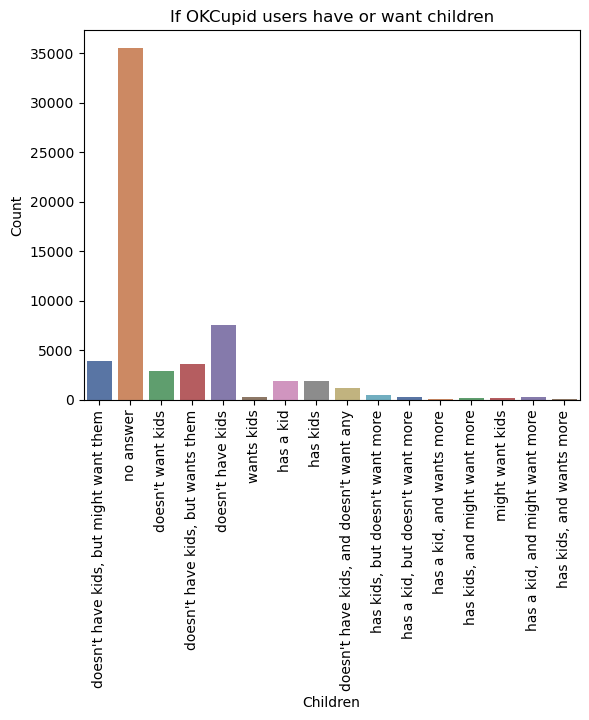

In [28]:
sns.countplot(data=df, x='children', palette='deep')
plt.title("If OKCupid users have or want children")
plt.xlabel("Children")
plt.xticks(rotation=90)
plt.ylabel("Count")
plt.show()

This column contains two different pieces of information: if the user *has* kids and if the user *wants* kids. I want to split the data included here into two separate columns: *has_children* and *wants_children*.

### Orientation

### Pets

### Religion

In [29]:
df.religion.value_counts()

religion
no answer                                     20226
agnosticism                                    2724
other                                          2691
agnosticism but not too serious about it       2636
agnosticism and laughing about it              2496
catholicism but not too serious about it       2318
atheism                                        2175
other and laughing about it                    2119
atheism and laughing about it                  2074
christianity                                   1957
christianity but not too serious about it      1952
other but not too serious about it             1554
judaism but not too serious about it           1517
atheism but not too serious about it           1318
catholicism                                    1064
christianity and somewhat serious about it      927
atheism and somewhat serious about it           848
other and somewhat serious about it             846
catholicism and laughing about it               726
jud

C:\Users\koral\AppData\Local\Temp\ipykernel_10464\3119499461.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='religion', palette='deep')


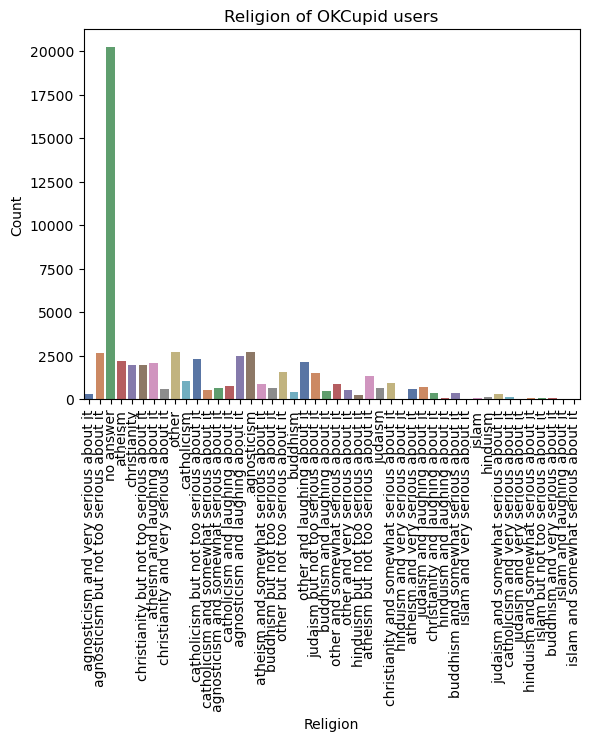

In [30]:
sns.countplot(data=df, x='religion', palette='deep')
plt.title("Religion of OKCupid users")
plt.xlabel("Religion")
plt.xticks(rotation=90)
plt.ylabel("Count")
plt.show()

As you can see in the value counts results above and the resulting countplot, there are several responses given for *religion* in the database. Similarly to the cleaning up of *diets* above, I have gone head and cleaned up the results for *religion* by merging any mention of a specific religious practice into one category:

In [31]:
df['religion'] = df['religion'].str.split().str[0]

In [32]:
df['religion'].replace('no', 'no answer', inplace=True)

C:\Users\koral\AppData\Local\Temp\ipykernel_10464\3799820311.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['religion'].replace('no', 'no answer', inplace=True)


C:\Users\koral\AppData\Local\Temp\ipykernel_10464\1144721032.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='religion', palette='deep')


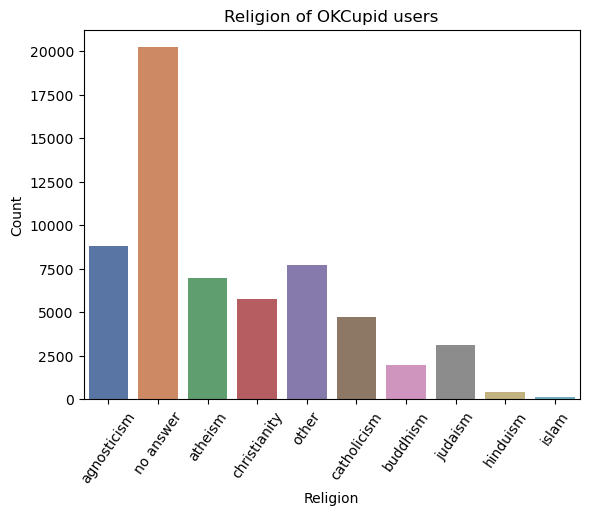

In [33]:
sns.countplot(data=df, x='religion', palette='deep')
plt.title("Religion of OKCupid users")
plt.xlabel("Religion")
plt.xticks(rotation=55)
plt.ylabel("Count")
plt.show()

### Sex

### Astrological sign

### Smokes

The countplot below shows the smoking habits of users. The majority of users do not smoke.

C:\Users\koral\AppData\Local\Temp\ipykernel_10464\2617854384.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='smokes', palette='deep', gap=0.2)


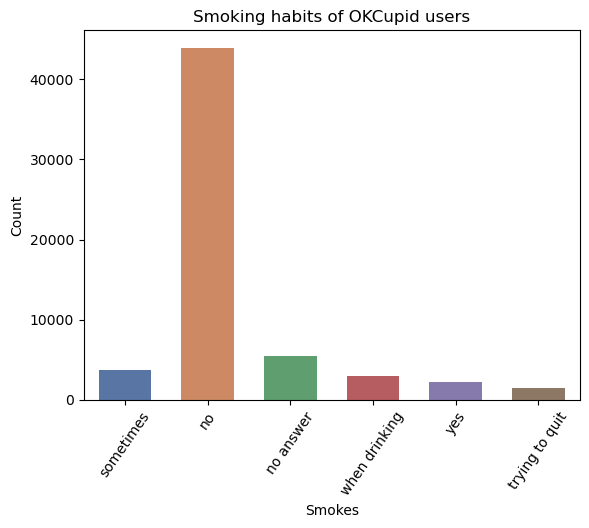

In [34]:
sns.countplot(data=df, x='smokes', palette='deep', gap=0.2)
plt.title("Smoking habits of OKCupid users")
plt.xlabel("Smokes")
plt.xticks(rotation=55)
plt.ylabel("Count")
plt.show()

### Languages

### Relationship status

## Random Forest Classifier (Version 1)

### Data preprocessing

Before I start building the random forest classifier being used to predict the diets of OKCupid users, let's revisit the distribution of diets again.

C:\Users\koral\AppData\Local\Temp\ipykernel_10464\4052258524.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='diet', palette='deep')


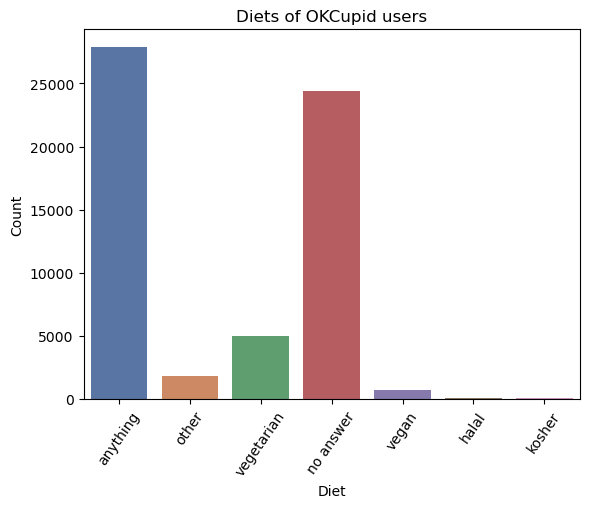

In [35]:
sns.countplot(data=df, x='diet', palette='deep')
plt.title("Diets of OKCupid users")
plt.xlabel("Diet")
plt.xticks(rotation=55)
plt.ylabel("Count")
plt.show()

What is the percentage of profiles for each dietary type?

In [36]:
df.diet.value_counts(normalize=True)

diet
anything      0.465102
no answer     0.406950
vegetarian    0.083175
other         0.029860
vegan         0.011711
kosher        0.001918
halal         0.001284
Name: proportion, dtype: float64

The features that are being used in the random forest classifier to predict the unknown diets are *religion*, *body type*, and *education*. These features all contain categorical data. They must be transformed into numerical values using .get_dummies()

In [37]:
feature_cols = ['body_type', 'education', 'religion']

In [38]:
X = pd.get_dummies(df[feature_cols], drop_first=True)

In [39]:
y = df.diet

Now that the X and y variables have been set aside, now the train/test split can be performed, completing the preprocessing.

In [40]:
x_train, x_test, y_train, y_test = train_test_split(X, y, random_state=1, test_size=0.2)

### Building the model

Now I am instantiating the random forest classifier, fit, and score.

In [41]:
rf = RandomForestClassifier()

In [42]:
rf.fit(x_train, y_train)

RandomForestClassifier()

In [43]:
rf.score(x_test, y_test)

0.5250208507089241

In [44]:
print("Accuracy score for default random forest: " + str(round(rf.score(x_test, y_test)*100, 3)) + "%.")

Accuracy score for default random forest: 52.502%.


The accuracy score for this default random forest classifier came out to 52%. Let's go ahead and tune the classifier model to determine the best max depth and test data.

In [45]:
np.random.seed(0)
accuracy_train = []
accuracy_test = []
depths = range(1, 26)

for i in depths:
    rf = RandomForestClassifier(max_depth=i)
    rf.fit(x_train, y_train)
    y_pred = rf.predict(x_test)
    accuracy_test.append(accuracy_score(y_test, rf.predict(x_test)))
    accuracy_train.append(accuracy_score(y_train, rf.predict(x_train)))

best_acc = np.max(accuracy_test)
best_depth = depths[np.argmax(accuracy_test)]

In [46]:
print("Highest accuracy achieved when depth: " + str(best_depth))

Highest accuracy achieved when depth: 7


In [47]:
print("Highest accuracy on test set is: " + str(round(best_acc * 100, 3)) + "%.")

Highest accuracy on test set is: 53.228%.


### Evaluating the model

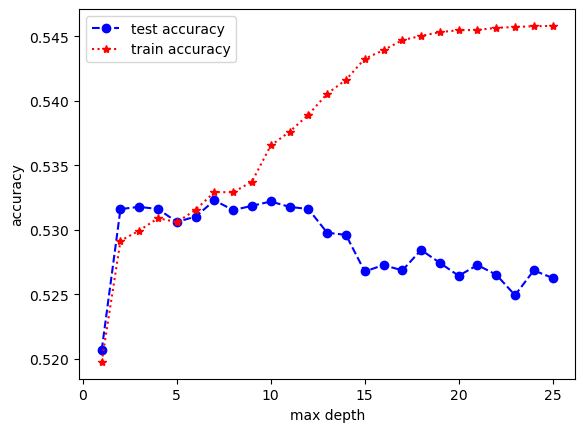

In [48]:
plt.figure(2)
plt.plot(depths, accuracy_test, 'bo--', depths, accuracy_train, 'r*:')
plt.legend(['test accuracy', 'train accuracy'])
plt.xlabel('max depth')
plt.ylabel('accuracy')
plt.show()

In [49]:
best_rf = RandomForestClassifier(max_depth=best_depth)
best_rf.fit(x_train, y_train)
feature_imp_df = pd.DataFrame(zip(x_train.columns, best_rf.feature_importances_),  columns=['feature', 'importance'])
print('Top 5 random forest features:')
print(feature_imp_df.sort_values('importance', ascending=False).iloc[0:5])

Top 5 random forest features:
                feature  importance
6   body_type_no answer    0.417125
19  education_no answer    0.192243
30   religion_no answer    0.150252
23     religion_atheism    0.029706
3         body_type_fit    0.026931


The features used for this random forest classifier each features large numbers of 'no answer' values. Therefore, for all three features, the 'no answer' response was given the highest importance. This likely impacted the accuracy score and the decline in the test accuracy as shown in the above line graph.

## Random Forest Classifier Model (Version 2):

Following the outcome of the first random forest classifier I built and evaluated above, I will build a new, separate classifier using the same supervised learning method but with a new list of features to train to predict the diets of OKCupid users. For this classifier, the features will consist of variables with no or very few 'no answer' responses (i.e. null values in the original dataframe).

The features chosen for this version of the random forest classifier are: *age*, *sex*, *drinks*, and *body_type*. *body_type* is the only feature retained from Version 1. Among the other three features selected, *age* and *sex* were chosen because they had no missing values (no 'no answer' responses). *drinks* was chosen becasue...

### Data preprocessing

Before I start building the random forest classifier being used to predict the diets of OKCupid users, let's revisit the distribution of diets again.

C:\Users\koral\AppData\Local\Temp\ipykernel_10464\4052258524.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='diet', palette='deep')


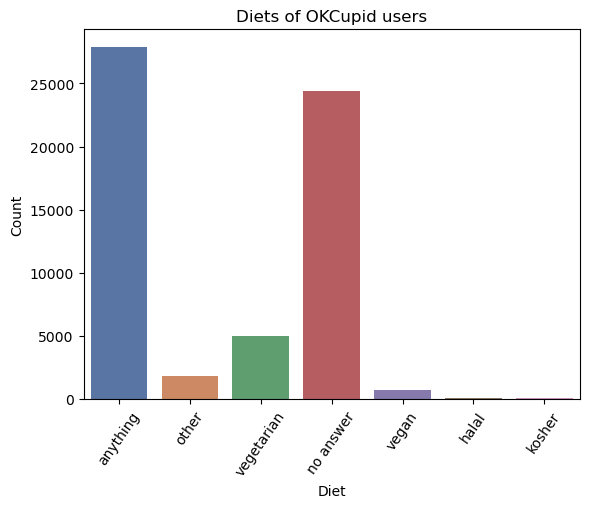

In [50]:
sns.countplot(data=df, x='diet', palette='deep')
plt.title("Diets of OKCupid users")
plt.xlabel("Diet")
plt.xticks(rotation=55)
plt.ylabel("Count")
plt.show()

What is the percentage of profiles for each dietary type?

In [51]:
df.diet.value_counts(normalize=True)

diet
anything      0.465102
no answer     0.406950
vegetarian    0.083175
other         0.029860
vegan         0.011711
kosher        0.001918
halal         0.001284
Name: proportion, dtype: float64

The features that are being used in the random forest classifier to predict the unknown diets are *age*, *sex*, *body type*, and *drinks*. With the exception of *age*, these features all contain categorical data. They must be transformed into numerical values using .get_dummies()

In [52]:
feature_cols = ['age', 'sex', 'body_type', 'drinks']

In [53]:
X = pd.get_dummies(df[feature_cols], drop_first=True)

In [54]:
y = df.diet

Now that the X and y variables have been set aside, now the train/test split can be performed, completing the preprocessing.

In [55]:
x_train, x_test, y_train, y_test = train_test_split(X, y, random_state=1, test_size=0.2)

### Buildling the model

Now I am instantiating the random forest classifier, fit, and score.

In [56]:
rf = RandomForestClassifier()

In [57]:
rf.fit(x_train, y_train)

RandomForestClassifier()

In [59]:
rf.score(x_test, y_test)

0.5073394495412844

In [60]:
print("Accuracy score for default random forest: " + str(round(rf.score(x_test, y_test)*100, 3)) + "%.")

Accuracy score for default random forest: 50.734%.


The accuracy score for this default random forest classifier came out to 50%. Let's go ahead and tune the classifier model to determine the best max depth and test data.

In [61]:
np.random.seed(0)
accuracy_train = []
accuracy_test = []
depths = range(1, 26)

for i in depths:
    rf = RandomForestClassifier(max_depth=i)
    rf.fit(x_train, y_train)
    y_pred = rf.predict(x_test)
    accuracy_test.append(accuracy_score(y_test, rf.predict(x_test)))
    accuracy_train.append(accuracy_score(y_train, rf.predict(x_train)))

best_acc = np.max(accuracy_test)
best_depth = depths[np.argmax(accuracy_test)]

In [62]:
print("Highest accuracy achieved when depth: " + str(best_depth))

Highest accuracy achieved when depth: 10


In [63]:
print("Highest accuracy on test set is: " + str(round(best_acc * 100, 3)) + "%.")

Highest accuracy on test set is: 53.019%.


### Evaluating the model

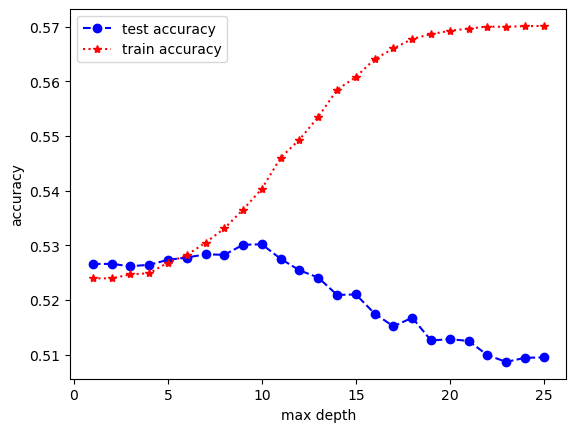

In [64]:
plt.figure(2)
plt.plot(depths, accuracy_test, 'bo--', depths, accuracy_train, 'r*:')
plt.legend(['test accuracy', 'train accuracy'])
plt.xlabel('max depth')
plt.ylabel('accuracy')
plt.show()

In [65]:
best_rf = RandomForestClassifier(max_depth=best_depth)
best_rf.fit(x_train, y_train)
feature_imp_df = pd.DataFrame(zip(x_train.columns, best_rf.feature_importances_),  columns=['feature', 'importance'])
print('Top 5 random forest features:')
print(feature_imp_df.sort_values('importance', ascending=False).iloc[0:5])

Top 5 random forest features:
                feature  importance
0                   age    0.335726
8   body_type_no answer    0.314372
14     drinks_no answer    0.136708
1                 sex_m    0.055410
18      drinks_socially    0.027116
